
## Lab 3: Logistic Regression, Log-Loss Cost Function & Gradient Descent for Optimization

## Learning Objectives

By the end of this lab, you will be able to:

1. Explain why **Linear Regression is unsuitable for classification** problems.
2. Understand and implement the **Sigmoid function**.
3. Build the **Logistic Regression** hypothesis and understand the **decision boundary**.
4. Understand why **Log-Loss (Binary Cross-Entropy)** is used instead of MSE, and implement it.
5. Derive and implement **Gradient Descent for Logistic Regression**.
6. Evaluate a classifier using **Accuracy** and a **Confusion Matrix**.
7. Compare your implementation against Scikit-learn's `LogisticRegression`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Used for comparison and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. From Regression to Classification

Last lab, our target `y` was a **continuous number** (house price). But many real problems ask a **yes/no** question instead:

- Will a student **pass or fail** based on study hours?
- Is an email **spam or not spam**?
- Does a patient **have a disease or not**?

These are **classification problems** the target `y` only takes values like `0` or `1`.

### Why not just use Linear Regression here?

If we tried `ŷ = wx + b` on a 0/1 target, two problems appear:

1. **Unbounded output** `wx + b` can produce any value (e.g., -5 or 120), but a probability must be between 0 and 1.
2. **Poor fit for binary outcomes** a straight line does not naturally model a sharp 0-to-1 transition.

We need a function that **squashes** any real number into the range **(0, 1)**, so it can be interpreted as a probability. This is exactly what the **Sigmoid function** does.

## 2. The Sigmoid Function

The Sigmoid (logistic) function is defined as:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

**Properties:**
- As `z → +∞`, `σ(z) → 1`
- As `z → -∞`, `σ(z) → 0`
- At `z = 0`, `σ(z) = 0.5`

This gives us a smooth S-shaped curve that we can interpret as a **probability**.

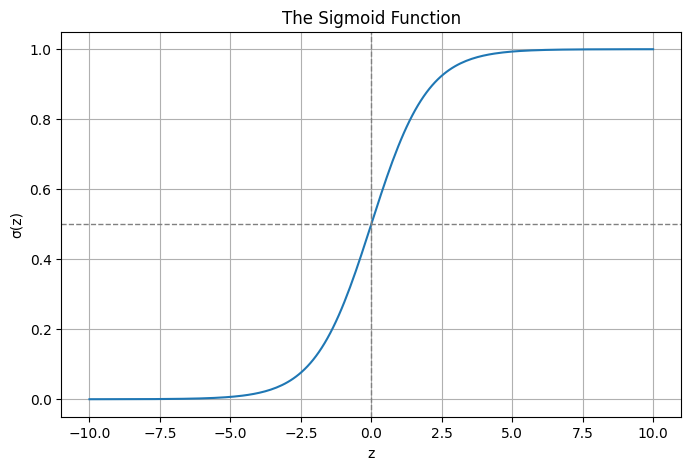

In [2]:
def sigmoid(z):
    """Compute the sigmoid of z (works on scalars or numpy arrays)."""
    return 1 / (1 + np.exp(-z))

# Visualize the sigmoid curve, 200 values of z
z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid_values)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.title("The Sigmoid Function")
plt.grid(True)
plt.show()

## 3. The Logistic Regression Hypothesis

Logistic Regression works in two steps:

1. Compute a **linear combination**, just like before:
   $$ z = wx + b $$
2. Pass it through the **sigmoid function** to get a probability:
   $$ \hat{y} = \sigma(z) = \frac{1}{1 + e^{-(wx + b)}} $$


### Decision Boundary

To turn a probability into a **class label**, we apply a threshold (commonly 0.5):

$$ \text{class} = \begin{cases} 1 & \text{if } \hat{y} \geq 0.5 \\ 0 & \text{if } \hat{y} < 0.5 \end{cases} $$

Since `σ(z) = 0.5` exactly when `z = 0`, the decision boundary is simply the line **`wx + b = 0`**.

In [3]:
def predict_proba(x, w, b):

    z = w * x + b
    return sigmoid(z)

def predict_class(x, w, b, threshold=0.5):
    """Return the predicted class label (0 or 1)."""
    return (predict_proba(x, w, b) >= threshold).astype(int)

## 4. Example Dataset: Study Hours vs Pass/Fail

### Feature (X)
Hours a student studied for an exam.

### Target (y)
Whether the student **passed (1)** or **failed (0)**.

In [4]:
# Study hours (feature)
X = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0,
              5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0])

# Pass (1) / Fail (0)
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
              1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

data = pd.DataFrame({"Study Hours": X, "Passed": y})
data

,Study Hours,Passed
0,0.5,0
1,1.0,0
2,1.5,0
3,2.0,0
4,2.5,0
5,3.0,0
6,3.5,1
7,4.0,0
8,4.5,1
9,5.0,0


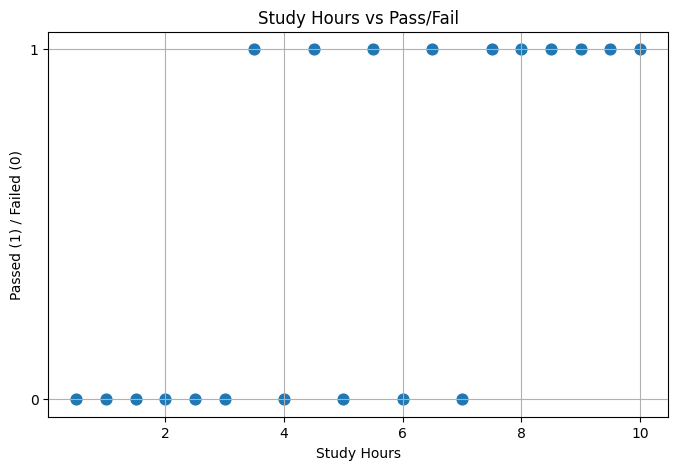

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=60)
plt.xlabel("Study Hours")
plt.ylabel("Passed (1) / Failed (0)")
plt.title("Study Hours vs Pass/Fail")
plt.yticks([0, 1])
plt.grid(True)
plt.show()

## 5. Why Not Use Mean Squared Error?

We used **Mean Squared Error (MSE)** for Linear Regression, but Logistic Regression uses a different cost function.

### Why?

**MSE is not ideal for probabilities.**

Logistic Regression predicts probabilities, so we need a cost function that strongly penalizes **confident wrong predictions**.

- **Actual = 1, Predicted probability = 0.95** → Very small loss ✅
- **Actual = 1, Predicted probability = 0.05** → Very large loss ❌

In [6]:
def compute_log_loss(X, y, w, b):

    n = len(y)
    y_hat = predict_proba(X, w, b)

    # Small epsilon to avoid log(0)
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    loss = -(1/n) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss

In [7]:
# Try a couple of parameter values and observe the cost
for w_try, b_try in [(0, 0), (0.5, -2), (1, -5)]:
    cost = compute_log_loss(X, y, w_try, b_try)
    print(f"w={w_try}, b={b_try} -> Log-Loss = {cost:.4f}")

w=0, b=0 -> Log-Loss = 0.6931
w=0.5, b=-2 -> Log-Loss = 0.4544
w=1, b=-5 -> Log-Loss = 0.4152


## 6. Gradient Descent for Logistic Regression

The **update rule** is the same form you already know from Week 2:

$$ w = w - \alpha \frac{\partial J}{\partial w}, \qquad b = b - \alpha \frac{\partial J}{\partial b} $$

What's different is **how the gradients are derived**, because `ŷ` now goes through the sigmoid function. Interestingly, after the calculus works out, the gradients of Log-Loss have a form that *looks* similar to Linear Regression's:

$$ \frac{\partial J}{\partial w} = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)\, x_i \qquad\qquad \frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i) $$

**But `ŷ_i` here means `σ(wx_i + b)`, not `wx_i + b` directly** — that's the key difference from linear regression.

In [8]:
def compute_gradients_logistic(X, y, w, b):

    n = len(y)
    y_hat = predict_proba(X, w, b)

    dj_dw = (1/n) * np.sum((y_hat - y) * X)
    dj_db = (1/n) * np.sum(y_hat - y)

    return dj_dw, dj_db

In [9]:
def logistic_gradient_descent(X, y, w_initial, b_initial, learning_rate, iterations):
    """
    Perform Batch Gradient Descent for Logistic Regression.

    Returns
    -------
    w, b : learned parameters
    cost_history : list of Log-Loss values recorded every iteration
    """
    w = w_initial
    b = b_initial
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradients_logistic(X, y, w, b)

        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

        cost = compute_log_loss(X, y, w, b)
        cost_history.append(cost)

    return w, b, cost_history

> **Reminder:** Just like in Week 2, we will standardize `X` before training so Gradient Descent converges smoothly. (You already know why — refer back to Week 2 if you need a refresher.)

In [10]:
X_mean = np.mean(X)
X_std = np.std(X)
X_scaled = (X - X_mean) / X_std

## 7. Training the Logistic Regression Model

In [11]:
w_initial = 0.0
b_initial = 0.0
learning_rate = 0.5
iterations = 1000

w_scaled, b_scaled, cost_history = logistic_gradient_descent(
    X_scaled, y, w_initial, b_initial, learning_rate, iterations
)

print("Learned w:", w_scaled)
print("Learned b:", b_scaled)
print("Final Log-Loss:", cost_history[-1])

Learned w: 2.186321079749676
Learned b: -1.9428902930940195e-17
Final Log-Loss: 0.39982636457997367


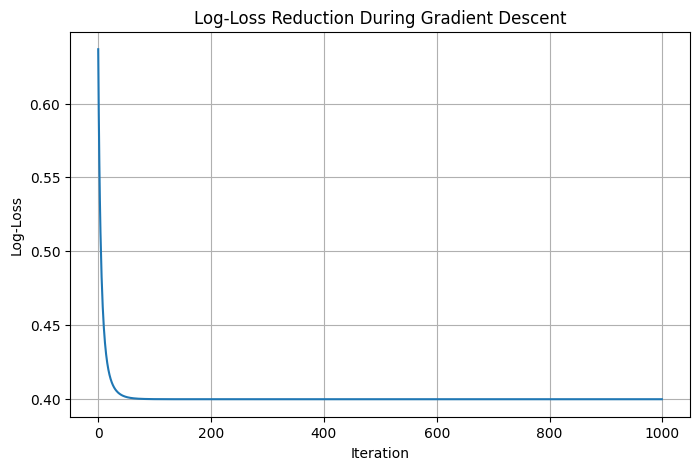

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Log-Loss")
plt.title("Log-Loss Reduction During Gradient Descent")
plt.grid(True)
plt.show()

## 8. Comparing Learning Rates

Just like last lab, the learning rate controls how big each Gradient Descent step is. Let's compare a few values directly on the Log-Loss curve.

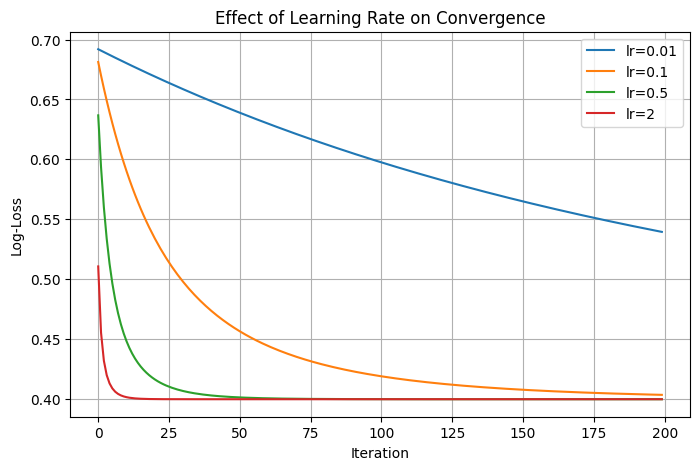

In [13]:
learning_rates = [0.01, 0.1, 0.5, 2]

plt.figure(figsize=(8, 5))
for lr in learning_rates:
    _, _, history = logistic_gradient_descent(X_scaled, y, 0.0, 0.0, lr, 200)
    plt.plot(history, label=f"lr={lr}")

plt.xlabel("Iteration")
plt.ylabel("Log-Loss")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.grid(True)
plt.show()

## 9. Visualizing the Fitted Sigmoid Curve and Decision Boundary

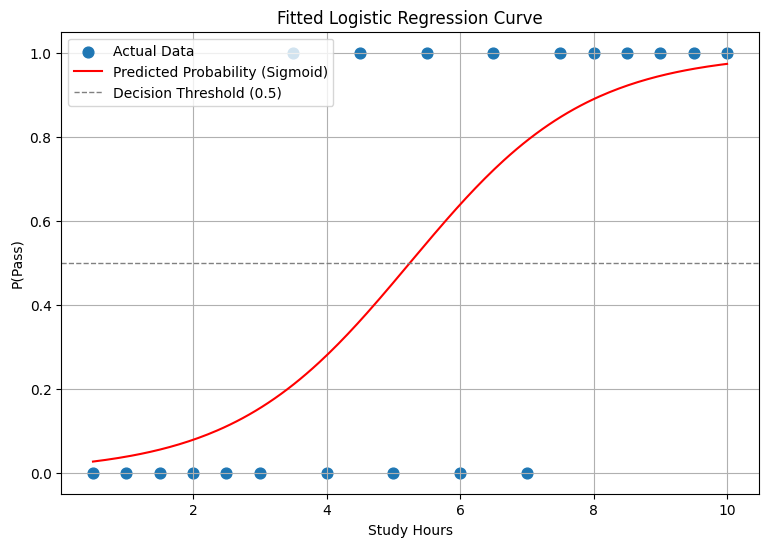

In [14]:
x_line = np.linspace(X.min(), X.max(), 200)
x_line_scaled = (x_line - X_mean) / X_std
y_line_proba = predict_proba(x_line_scaled, w_scaled, b_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X, y, s=60, label="Actual Data")
plt.plot(x_line, y_line_proba, color='red', label="Predicted Probability (Sigmoid)")
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label="Decision Threshold (0.5)")
plt.xlabel("Study Hours")
plt.ylabel("P(Pass)")
plt.title("Fitted Logistic Regression Curve")
plt.legend()
plt.grid(True)
plt.show()

## 10. Evaluating the Classifier

For regression, we used MSE and R². For **classification**, we instead use metrics like:

- **Accuracy:** proportion of correctly classified examples.
- **Confusion Matrix:** breaks down predictions into True Positives, True Negatives, False Positives, and False Negatives.

Accuracy: 0.8


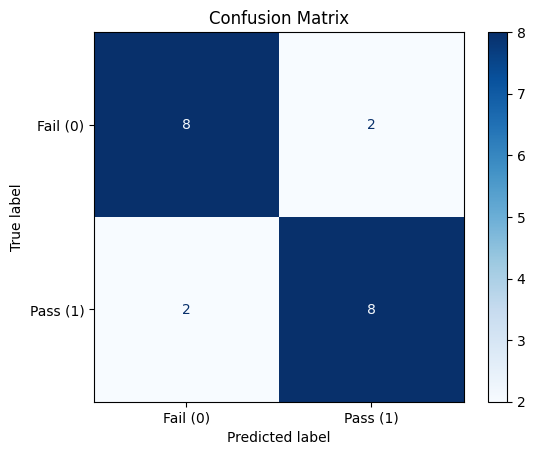

In [15]:
y_pred = predict_class(X_scaled, w_scaled, b_scaled)

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail (0)", "Pass (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## 11. Comparing with Scikit-learn

Let's confirm our from-scratch implementation is reasonable by comparing it against Scikit-learn's `LogisticRegression`.

In [16]:
# Scikit-learn expects X as a 2D array
X_2d = X.reshape(-1, 1)

sk_model = LogisticRegression()
sk_model.fit(X_2d, y)

sk_pred = sk_model.predict(X_2d)
sk_accuracy = accuracy_score(y, sk_pred)

comparison = pd.DataFrame({
    "Study Hours": X,
    "Actual": y,
    "Our Model Prediction": y_pred,
    "Scikit-learn Prediction": sk_pred
})

print("Our Model Accuracy:       ", accuracy)
print("Scikit-learn Accuracy:    ", sk_accuracy)
comparison

Our Model Accuracy:        0.8
Scikit-learn Accuracy:     0.8


,Study Hours,Actual,Our Model Prediction,Scikit-learn Prediction
0,0.5,0,0,0
1,1.0,0,0,0
2,1.5,0,0,0
3,2.0,0,0,0
4,2.5,0,0,0
5,3.0,0,0,0
6,3.5,1,0,0
7,4.0,0,0,0
8,4.5,1,0,0
9,5.0,0,0,0


### 📝 Practice Cell

Change the `learning_rate` and `iterations` values in Section 7 and re-run training to see how the Log-Loss curve changes.

*(This is just practice — the graded task will be given separately.)*

In [ ]:
# Your practice code here



## 12. Extending to Two Features

Real datasets usually have more than one feature. Let's quickly extend our model to **two features**: Study Hours and Attendance (%).

With two features, the hypothesis becomes:

$$ z = w_1 x_1 + w_2 x_2 + b, \qquad \hat{y} = \sigma(z) $$

The decision boundary is now a **line in 2D** instead of a single point.

In [ ]:
# Two features: Study Hours, Attendance (%)
X2 = np.array([
    [0.5, 40], [1.0, 45], [1.5, 50], [2.0, 55], [2.5, 60],
    [3.0, 65], [3.5, 70], [4.0, 60], [4.5, 80], [5.0, 65],
    [5.5, 85], [6.0, 70], [6.5, 90], [7.0, 75], [7.5, 92],
    [8.0, 88], [8.5, 95], [9.0, 90], [9.5, 97], [10.0, 98]
])
y2 = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# Standardize both features
X2_mean = X2.mean(axis=0)
X2_std = X2.std(axis=0)
X2_scaled = (X2 - X2_mean) / X2_std

# Reuse sklearn to fit quickly (keeps this section short)
sk_model_2f = LogisticRegression()
sk_model_2f.fit(X2_scaled, y2)

acc_2f = accuracy_score(y2, sk_model_2f.predict(X2_scaled))
print("Accuracy with two features:", acc_2f)

In [ ]:
# Visualize the 2D decision boundary
w1, w2 = sk_model_2f.coef_[0]
b2 = sk_model_2f.intercept_[0]

x1_range = np.linspace(X2_scaled[:, 0].min() - 1, X2_scaled[:, 0].max() + 1, 100)
x2_boundary = -(w1 * x1_range + b2) / w2

plt.figure(figsize=(8, 6))
plt.scatter(X2_scaled[y2 == 0][:, 0], X2_scaled[y2 == 0][:, 1], label="Fail (0)", s=60)
plt.scatter(X2_scaled[y2 == 1][:, 0], X2_scaled[y2 == 1][:, 1], label="Pass (1)", s=60)
plt.plot(x1_range, x2_boundary, color='black', linestyle='--', label="Decision Boundary")
plt.xlabel("Study Hours (scaled)")
plt.ylabel("Attendance % (scaled)")
plt.title("Two-Feature Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

### 📝 Practice Cell

Add one more data point of your own to `X2` and `y2` (pick reasonable study hours/attendance values and a 0 or 1 label), re-fit `sk_model_2f`, and re-plot the decision boundary.

*(This is just practice — the graded task will be given separately.)*

In [ ]:
# Your practice code here

